# SVM Decision Boundaries & Hyperparameters

Support Vector Machines (SVM) find optimal separating hyperplanes for classification. When data is non-linearly separable, the kernel trick projects features into higher-dimensional spaces. This project generates a synthetic "moons" dataset and trains SVM models with Linear, Polynomial, and Radial Basis Function (RBF) kernels to visualize classification boundaries.



<cell>:24: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



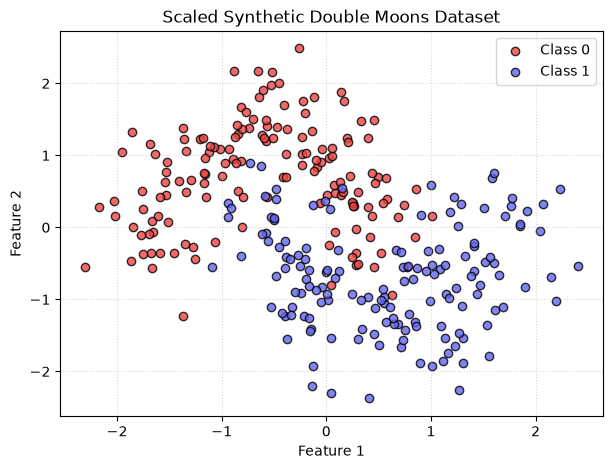

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Generate synthetic double moon cluster dataset
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)

# Preprocessing: standard scaling is critical for distance-based SVM models
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Scatter plot of scaled dataset
plt.figure(figsize=(7, 5))
plt.scatter(X_scaled[y == 0, 0], X_scaled[y == 0, 1], color='#EF4444', label='Class 0', edgecolors='k', alpha=0.8)
plt.scatter(X_scaled[y == 1, 0], X_scaled[y == 1, 1], color='#6366F1', label='Class 1', edgecolors='k', alpha=0.8)
plt.title("Scaled Synthetic Double Moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()



## Classifier Training & Grid Configuration

We define four distinct SVM configurations to observe boundary shapes:
1. **Linear Kernel**: Assumes linear separation limits.
2. **Polynomial Kernel (Degree 3)**: Models polynomial curves.
3. **RBF Kernel ($\gamma = 0.5$)**: Smooth radial boundaries.
4. **RBF Kernel ($\gamma = 4.0$)**: Tight radial boundaries focusing on local samples.



In [2]:
# Define models
models = {
    "Linear Kernel (C=1.0)": SVC(kernel='linear', C=1.0),
    "Polynomial (Degree=3, C=1.0)": SVC(kernel='poly', degree=3, C=1.0),
    "RBF Kernel (gamma=0.5, C=1.0)": SVC(kernel='rbf', gamma=0.5, C=1.0),
    "RBF Kernel (gamma=4.0, C=1.0)": SVC(kernel='rbf', gamma=4.0, C=1.0)
}

# Meshgrid coordinates helper for plotting boundaries
x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))



## SVM Boundary Visualization Dashboard

We fit each SVM model, calculate predictions, report test accuracies, and plot their respective decision boundaries along with support vectors in a 2x2 grid.



<cell>:34: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



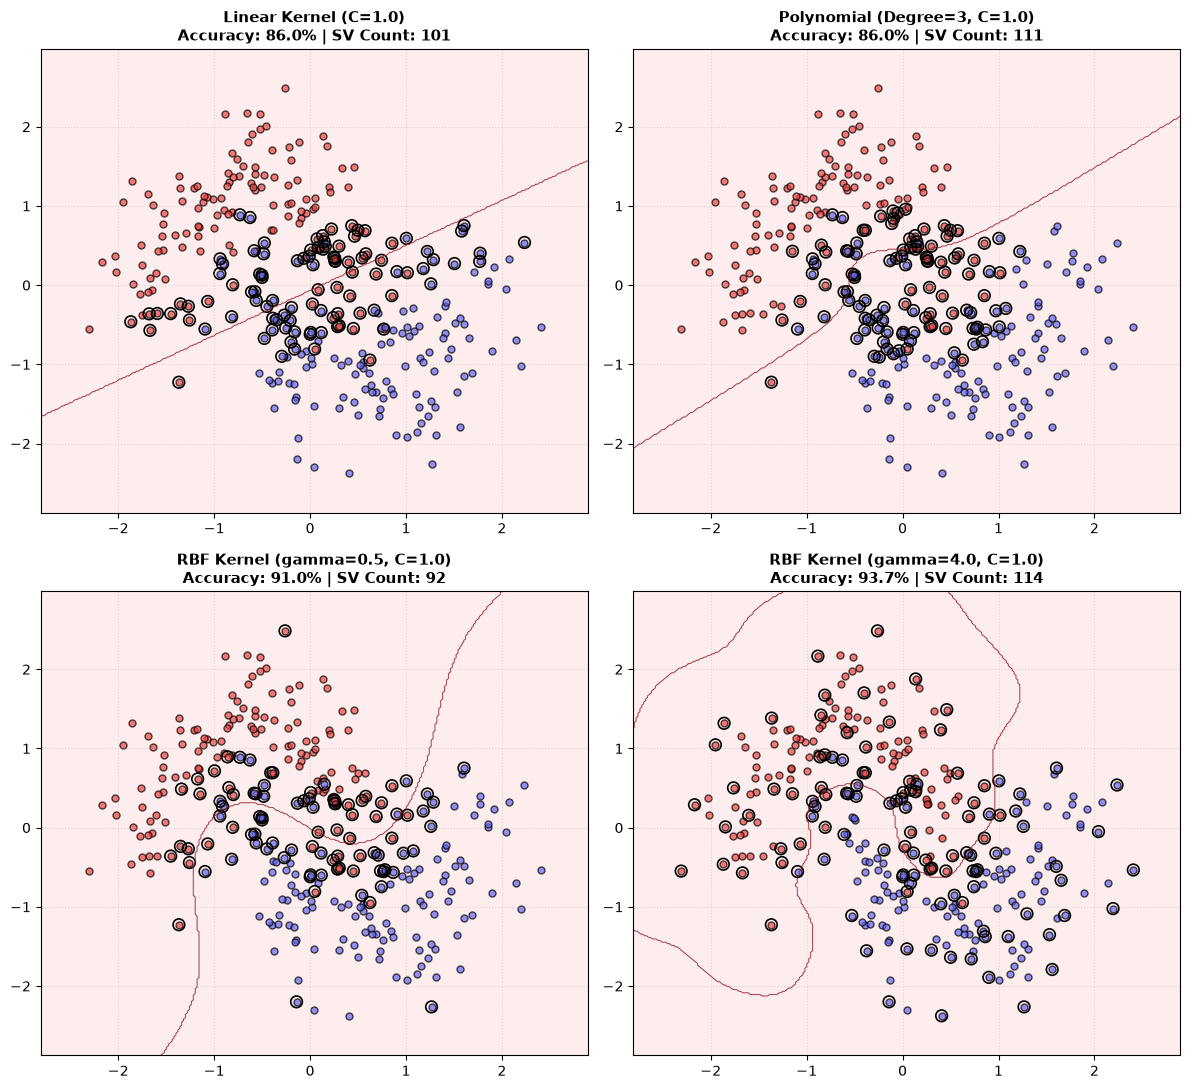

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 11))
axes_flat = axes.flatten()

for i, (name, clf) in enumerate(models.items()):
    ax = axes_flat[i]
    
    # Fit model
    clf.fit(X_scaled, y)
    y_pred = clf.predict(X_scaled)
    acc = accuracy_score(y, y_pred)
    
    # Predict over grid mesh
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot decision boundary contour
    ax.contourf(xx, yy, Z, alpha=0.2, colors=['#FCA5A5', '#C7D2FE'])
    ax.contour(xx, yy, Z, colors=['#991B1B', '#3730A3'], linewidths=0.5, levels=[0.5])
    
    # Plot data points
    ax.scatter(X_scaled[y == 0, 0], X_scaled[y == 0, 1], color='#EF4444', s=25, edgecolors='k', alpha=0.7, label='Class 0')
    ax.scatter(X_scaled[y == 1, 0], X_scaled[y == 1, 1], color='#6366F1', s=25, edgecolors='k', alpha=0.7, label='Class 1')
    
    # Highlight support vectors (hollow black markers)
    sv = clf.support_vectors_
    ax.scatter(sv[:, 0], sv[:, 1], s=70, facecolors='none', edgecolors='black', linewidths=1.2, label='Support Vector')
    
    ax.set_title(f"{name}\nAccuracy: {acc*100:.1f}% | SV Count: {len(sv)}", fontsize=11, fontweight='bold')
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()
